In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
from torchinfo import summary

import h5py
import scipy.stats
from scipy.stats import median_abs_deviation

from matplotlib import rcParams
rcParams["font.sans-serif"] = ["IBM Plex Sans"]
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from tqdm import tqdm

# Construct variants training and validation datasets

In [3]:
variants_dnase = pd.read_parquet(
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v4/output/non_aggregated.all.parquet"
)
# variants_atac = pd.read_parquet(
#     "/net/seq/data2/projects/sabramov/ENCODE4/atac-cavs/output/non_aggregated.all.parquet"
# )

variants = variants_dnase

In [4]:
variants["total_counts"] = variants.ref_counts + variants.alt_counts

passed_read_count = (variants.total_counts > 20) & (variants.ref_counts > 0) & (variants.alt_counts > 0)
signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
neg = variants.FDR_sample > 0.5

positives = variants[passed_read_count & signif]
negatives = variants[passed_read_count & neg].sample(n=len(positives))

examples = pd.concat([positives, negatives])
examples = examples.groupby(["#chr", "start", "ref", "sample_id"]).filter(lambda x: len(x)==1)

Text(0.5, 0, 'LFC variant effect')

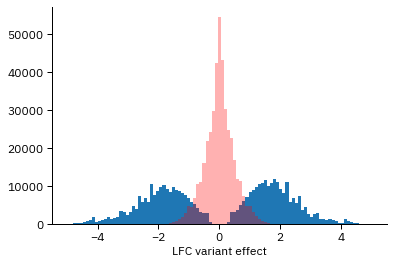

In [7]:
bins = np.linspace(-5, 5, 100)
h = plt.hist(positives.logit_es, bins=bins)
h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
plt.xlabel("LFC variant effect")

### Sample training and validation samples

In [8]:
columns = [
    "#chr",
    "start",
    "ref",
    "alt",
    "ref_counts",
    "total_counts",
    "BAD",
    "logit_es",
    "sample_id",
    "FDR_sample",
]

dataset = examples[columns].rename(columns={"#chr": "chrom", "start": "pos"})

In [9]:
def df_to_h5(path, df: pd.DataFrame):
    with h5py.File(path, "w") as f:
        for column in df.columns:
            data = df[column].values

            if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(
                df[column]
            ):
                data = data.astype("S30")  # fixed-length byte strings

            f.create_dataset(column, data=data)


## loading df from h5
def df_from_h5(path):
    with h5py.File(path, "r") as f:
        data = {}
        for key in f.keys():
            arr = f[key][:]
            # Decode byte strings if needed
            if arr.dtype.kind == "S":
                arr = arr.astype(str)
            data[key] = arr
        return pd.DataFrame(data)

In [ ]:
train_df = dataset.sample(frac=0.9, random_state=1)
valid_df = dataset.drop(train_df.index)

train_df.shape, valid_df.shape

# df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.v2.h5", train_df)
# df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.v2.h5", valid_df)

In [11]:
valid_chr_df = dataset[dataset["chrom"].isin(["chr9", "chr22"])]
train_chr_df = dataset.drop(valid_chr_df.index)

train_chr_df.shape, valid_chr_df.shape

df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.chr-split.h5", train_chr_df)
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.chr-split.h5", valid_chr_df)

In [10]:
groups = dataset.groupby(["chrom", "pos", "ref", "alt"], as_index=False)

valid_variants_df = groups.filter(lambda x: np.random.rand() < 0.1)
train_variants_df = dataset.drop(valid_variants_df.index)

df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.var-split.h5", train_variants_df)
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.var-split.h5", valid_variants_df)

In [11]:
valid_variants_df.shape, train_variants_df.shape
#valid_variants_df.head()

((84114, 10), (762654, 10))

### Write datasets to H5 files

In [202]:
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.v2.h5", train_df)
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.v2.h5", valid_df)

# Testing, dataloader, model & loss function

In [12]:
from vinson.dataset import VariantEmbedDataset
from vinson.model import (
    CellEmbedding,
    BassetTrunkEmbed,  
    VariantEmbedModel, 
    VariantEmbedModelWrapper)
from vinson.loss import binomial_mixture_normed_loss, binomial_mixture_loss

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = VariantEmbedModel(trunk, embed)

### Load in dataset and dataloader

In [304]:
examples_file = "/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.var-split.h5"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10//continious_annotation/total_cutcounts.tsv"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

sample_genotype_file = (
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/output/meta+sample_ids.tsv"
)
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/phasing/output/all_phased.bed.gz"


dataset = VariantEmbedDataset(
    examples_file,
    embeddings_file,
    fasta_file,
    sample_genotype_file=sample_genotype_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
    jitter=0,
    noise=0,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

### Explore loss function

In [76]:
# Select a variant
variant = dataset[560]

# Read counts over variant
total_counts = torch.tensor(variant["total_counts"])
ref_counts = torch.tensor(variant["ref_counts"])
bad_score = torch.tensor(variant["bad_score"])  # BAD score
#tau = torch.tensor(0.5 * np.log(2))
tau = 0 # removes prior

# Observed log-fold change
lfc = torch.log(ref_counts / (total_counts - ref_counts))

# Cycle through LFC values to simulate gradient search
pred_lfc_logit = torch.linspace(-10, 10, 10_000)

nll = binomial_mixture_loss(
    pred_lfc_logit, 
    ref_counts,
    total_counts,
    bad_score,
    tau=tau, 
    reduction="none"
)

print(f"ref_counts = {ref_counts}")
print(f"total_counts = {total_counts}")
print(f"bad = {bad_score}")
print(f"tau = {tau}")
print(f"lfc min nll = {pred_lfc_logit[nll.argmin()]}")
print(f"lfc raw = {lfc}")

ref_counts = 22.0
total_counts = 23.0
bad = 1.0
tau = 0
lfc min nll = 3.091308832168579
lfc raw = 3.0910425186157227


Text(0.5, 1.0, 'NLL loss landscape for a single variant')

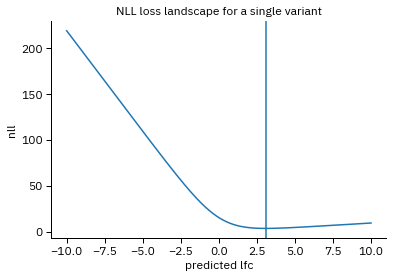

In [77]:
plt.plot(pred_lfc_logit, nll)
plt.axvline(lfc)

plt.xlabel("predicted lfc")
plt.ylabel("nll")

plt.title("NLL loss landscape for a single variant")

Text(0.5, 1.0, 'Normalized NLL loss landscape for a single variant')

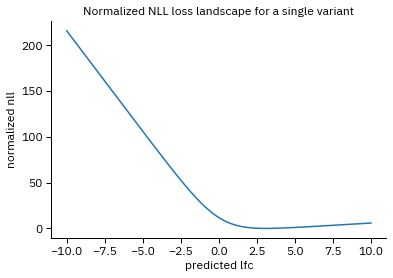

In [78]:
nll = binomial_mixture_normed_loss(
    pred_lfc_logit, 
    ref_counts, 
    total_counts, 
    bad_score, 
    reduction="none"
)

plt.plot(pred_lfc_logit, nll)

plt.xlabel("predicted lfc")
plt.ylabel("normalized nll")

plt.title("Normalized NLL loss landscape for a single variant")

# Train model

To train model edit and run the following script: ```sbatch train_variants.sh```

# Analyze, predict & interpret model

### Load in pre-trained variant model

In [294]:
pretrained_state_dict = torch.load(
    "models/variant_data_AUG3_with_warmup_and_decay_v2/checkpoints/epoch=19-step=119160-val_loss=3.1515.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model_dict = model.state_dict()
model_dict.update(pretrained_state_dict)
model.load_state_dict(model_dict, strict=False)

<All keys matched successfully>

### Predict variants (random batch)

In [331]:
batch = next(iter(dataloader))

X_seq_ref, X_seq_alt, X_embed, ref_counts, total_counts, bad_score, lfc = (
    batch["ohe_seq_hap1"],
    batch["ohe_seq_hap2"],
    batch["embed"],
    batch["ref_counts"],
    batch["total_counts"],
    batch["bad_score"],
    batch["lfc"],
)

# Estimated log-fold change
# lfc = (ref_counts / (total_counts - ref_counts)).log()

# Predict example with model
y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()

# Can evaluate different tau values -- -1 removes prior
tau = 0.5 * torch.tensor(2).log()
tau = -1

# Compute loss
loss = binomial_mixture_normed_loss(
    y, ref_counts, total_counts, bad_score, tau=tau, reduction="none"
)

print(f"loss = {loss.mean()}")

loss = 3.1485910415649414


Text(0.5, 1.0, 'Loss landscape for batch')

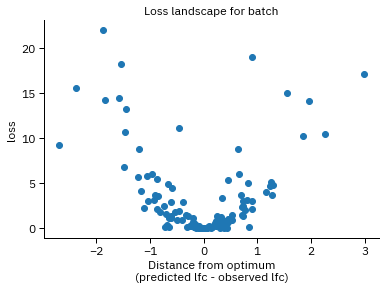

In [332]:
plt.scatter(y.detach() - lfc, loss.detach())
plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
plt.ylabel("loss")

plt.title("Loss landscape for batch")

### Plot the predicted vs. observed LFC 

Text(0.5, 1.0, 'Variant effect prediction from DNA sequence')

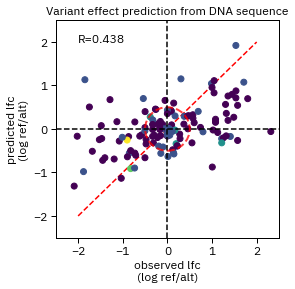

In [333]:
m, b = np.polyfit(lfc, y.detach(), 1)
pearsonr = scipy.stats.pearsonr(lfc, y.detach())

#plt.scatter(lfc, y.detach() * 1 / m + b, c=bad_score)
plt.scatter(lfc, y.detach(), c=bad_score)

plt.axvline(0, ls="--", color="k")
plt.axhline(0, ls="--", color="k")

plt.plot([-2, 2], [-2, 2], color="red", ls="--", zorder=-1)

plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

c = Circle((0,0), 0.5, ec='red', fc="none", lw=2, ls='--', alpha=0.75)
plt.gca().add_patch(c)

plt.gcf().set_size_inches(4, 4)

plt.xlabel("observed lfc\n(log ref/alt)")
plt.ylabel("predicted lfc\n(log ref/alt)")

plt.title("Variant effect prediction from DNA sequence")

### Contribution scores

In [330]:
from tangermeme.deep_lift_shap import deep_lift_shap, dinucleotide_shuffle
from vinson.utils import force_strict_ohe

def _passthrough(module, grad_input, grad_output):
    """No change made to gradients"""
    return None

# from vinson.model import _Sub
# You have to wrap the model and deep copy trunk and
# shared input tensors, otherwise DeepLIFT/SHAP
# does not converge.

inference_model = VariantEmbedModelWrapper(model)


TypeError: super(type, obj): obj must be an instance or subtype of type

In [303]:
print(model)

VariantEmbedModel(
  (trunk): BassetTrunkEmbed(
    (layer1): Sequential(
      (0): Conv1d(4, 300, kernel_size=(19,), stride=(1,), padding=same)
      (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    )
    (relu1): ReLU()
    (layer2): Sequential(
      (0): Conv1d(300, 200, kernel_size=(11,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu2): ReLU()
    (layer3): Sequential(
      (0): Conv1d(200, 200, kernel_size=(7,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu

In [302]:
i = torch.where(y<-0.4)[0]
i, lfc[i]

(tensor([  5,  10,  15,  23,  33,  35,  36,  43,  44,  46,  52,  53,  60,  69,
          71,  73,  75,  77,  78,  80,  83,  96,  99, 101, 105, 110, 115, 121,
         125]),
 tensor([-0.5881, -1.0109, -2.6183, -0.4562, -2.8520, -2.1810, -1.8479, -0.7217,
         -0.7465, -1.4443, -2.4216, -2.6835, -1.2282, -1.7823, -1.4498, -0.1976,
         -1.2556, -1.7182, -0.0131, -0.7571, -2.2287, -1.5967, -0.8077, -1.7865,
         -1.6644, -1.9165, -1.8942, -1.0782, -1.2282], dtype=torch.float64))

In [270]:
i = 89

y[i], lfc[i], total_counts[i]

(tensor(-0.5354, grad_fn=<SelectBackward0>),
 tensor(-1.2048, dtype=torch.float64),
 tensor(53.))

In [271]:
# This command shuffles the sequences but keeps the 
# variants constant
X_ref = force_strict_ohe(X_seq_ref[i:i+1])
X_alt = force_strict_ohe(X_seq_alt[i:i+1])

references_ = dinucleotide_shuffle(X_ref, n=20)

attribs_ref = deep_lift_shap(
    inference_model,
    X_ref,
    args=(X_alt, X_embed[i:i+1],),
    device="cpu",
    print_convergence_deltas=True,
    references=references_,
)


references_ = dinucleotide_shuffle(X_alt, n=20)


attribs_alt = deep_lift_shap(
    inference_model,
    X_alt,
    args=(X_ref, X_embed[i:i+1],),
    device="cpu",
    print_convergence_deltas=True,
    references=references_,
)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)


tensor([9.5367e-07, 9.5367e-07, 5.9605e-08, 2.3842e-07, 6.2585e-07, 4.7684e-07,
        4.7684e-07, 4.7684e-07, 4.7684e-07, 9.5367e-07, 4.7684e-07, 9.5367e-07,
        5.9605e-07, 1.4305e-06, 1.6689e-06, 0.0000e+00, 1.1921e-06, 1.9073e-06,
        2.3842e-07, 9.5367e-07], grad_fn=<AbsBackward0>)
tensor([9.5367e-07, 9.5367e-07, 1.3113e-06, 2.3842e-06, 4.7684e-07, 4.7684e-07,
        1.6838e-06, 1.4305e-06, 9.5367e-07, 4.1723e-07, 0.0000e+00, 4.7684e-07,
        1.4305e-06, 4.1723e-07, 4.7684e-07, 9.5367e-07, 1.9073e-06, 1.1921e-06,
        2.3842e-07, 8.3447e-07], grad_fn=<AbsBackward0>)


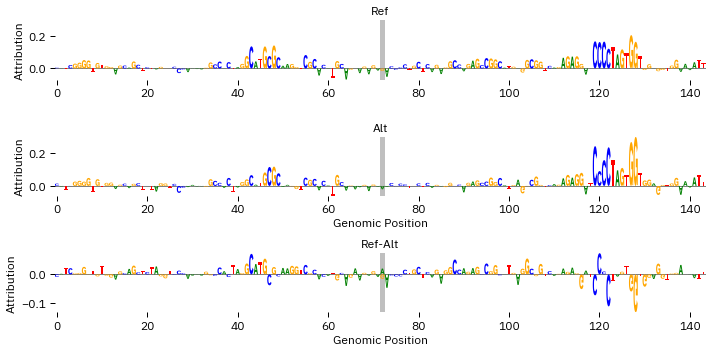

In [272]:
from tangermeme.plot import plot_logo

left, right = 600, -600

m = max(torch.max(attribs_ref[0, :, left:right]), torch.max(attribs_alt[0, :, left:right]))

plt.figure(figsize=(10, 5))
ax = plt.subplot(311)
plot_logo(attribs_ref[0, :, left:right], ax=ax)
plt.ylim(top=m)
plt.ylabel("Attribution")
plt.title("Ref")
plt.axvspan(71.5, 72.5, zorder=-1, fc="grey", alpha=0.5)

ax = plt.subplot(312)
plot_logo(attribs_alt[0, :, left:right], ax=ax)
plt.ylim(top=m)
plt.xlabel("Genomic Position")
plt.ylabel("Attribution")
plt.title("Alt")
plt.axvspan(71.5, 72.5, zorder=-1, fc="grey", alpha=0.5)

ax = plt.subplot(313)
plot_logo((attribs_ref-attribs_alt)[0, :, left:right], ax=ax)
plt.xlabel("Genomic Position")
plt.ylabel("Attribution")
plt.title("Ref-Alt")

plt.axvspan(71.5, 72.5, zorder=-1, fc="grey", alpha=0.5)

plt.tight_layout()
plt.show()